In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import joblib

# 定义文件夹路径
folder_path_qf = "qf_models"
# 权重定义
weights_qf = {'xgboost': 0.7 / 5, 'rf': 0.3 / 5}

# 加载测试集
df_qf = pd.read_excel('qf_models/train_set_new.xlsx', index_col=0)
X_test_qf = df_qf.drop(columns=['Precipitate Distribution',  'Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号'])
y_test_qf = df_qf['Yield_Strength']

# 选择一个样本
sample_index = 20  # 根据需要更改样本索引
sample = X_test_qf.iloc[sample_index].copy()
print(X_test_qf.iloc[sample_index,-5:],df_qf.iloc[sample_index]['Yield_Strength'])
# 特征及其变化范围
feature_ranges = {
    'Calculated Yield Strength': np.arange(50, 301, 20), # 已知
    'Grain Size': np.arange(5, 31, 1), # 已知

}
# 创建Excel文件以保存结果
with pd.ExcelWriter('qf_multiple_single_variable_analysis.xlsx', engine='openpyxl') as writer:
    for feature, ranges in feature_ranges.items():
        predictions_changes = []
        for value in ranges:
            modified_sample = sample.copy()
            modified_sample[feature] = value
            modified_sample_df = pd.DataFrame([modified_sample], columns=X_test_qf.columns)

            prediction_for_this_value = np.zeros(1)
            # 遍历每个模型进行预测
            for model_name, weight in weights_qf.items():
                for i in range(1,6):
                    model_path = f'{folder_path_qf}/{model_name}{i}_new.pkl'
                    model = joblib.load(model_path)
                    prediction_for_this_value += model.predict(modified_sample_df) * weight

            predictions_changes.append((value, prediction_for_this_value[0]))

        # 将结果转换为 DataFrame 并保存到 Excel的不同sheet中
        results_df = pd.DataFrame(predictions_changes, columns=[feature, 'Predicted Yield Strength'])
        results_df.to_excel(writer, sheet_name=feature, index=False)

print("Multi-feature single variable analysis completed and results saved to Excel.")


Grain Size                    12.000000
Habit Plane                    1.000000
Calculated Solid Solution     80.892125
Calculated Grain Boundary     90.605119
Calculated Yield Strength    186.497244
Name: 21, dtype: float64 311.0
Multi-feature single variable analysis completed and results saved to Excel.


In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import joblib

# 定义文件夹路径
folder_path_qf = "qf_models"
# 权重定义
weights_qf = {'xgboost': 0.7 / 5, 'rf': 0.3 / 5}

# 加载测试集
df_qf = pd.read_excel('qf_models/train_set_new.xlsx', index_col=0)
X_test_qf = df_qf.drop(columns=['Precipitate Distribution',  'Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号'])
y_test_qf = df_qf['Yield_Strength']

# 选择样本索引
# sample_indices = [50, 320, 470]  # 根据需要更改样本索引
sample_indices = np.arange(X_test_qf.shape[0])
print(X_test_qf.iloc[sample_indices,-5:],df_qf.iloc[sample_indices]['Yield_Strength'])

     Grain Size  Habit Plane  Calculated Solid Solution  \
0          4.00            0                  17.669989   
1         36.00            1                  57.602249   
2         50.00            5                  94.613373   
3          1.50            1                  76.138523   
5         15.00            0                  11.604694   
..          ...          ...                        ...   
754      130.00            1                  12.020723   
755       41.77            5                  61.765688   
756       30.00            2                  27.156102   
757       52.10            1                  23.809563   
758       30.00            1                  29.491375   

     Calculated Grain Boundary  Calculated Yield Strength  
0                   194.321983                 226.991971  
1                    48.504397                 121.106646  
2                    69.789053                 179.402426  
3                   262.520047                 353.

最大变化点所在行：
Calculated Yield Strength             190.000000
Predicted Yield Strength              217.056231
Change in Predicted Yield Strength     24.678930
Name: 7, dtype: float64

变化最大点的位置：7
对应的计算屈服强度：190.0
对应的预测屈服强度变化：24.678930400000013


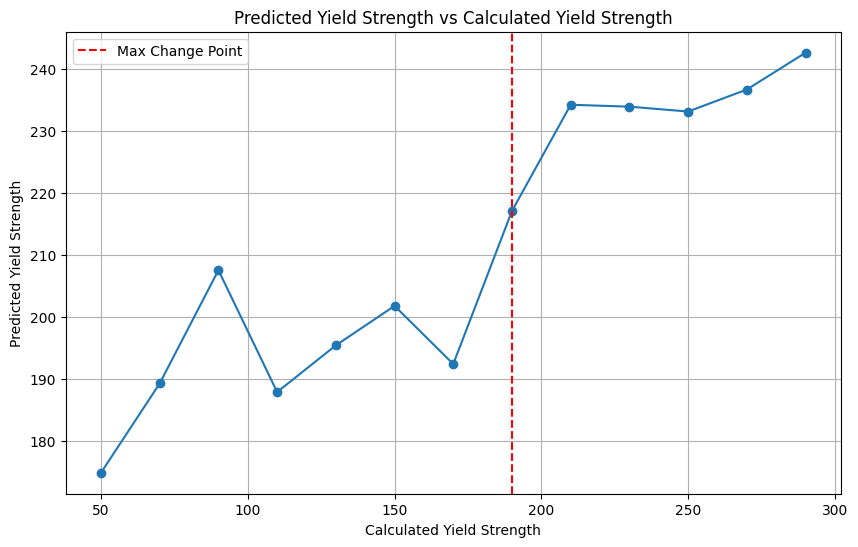

In [2]:
import pandas as pd

# 示例数据
data = {
    'Calculated Yield Strength': [50, 70, 90, 110, 130, 150, 170, 190, 210, 230, 250, 270, 290],
    'Predicted Yield Strength': [174.8570298, 189.2559711, 207.5047158, 187.8600811, 195.3893738, 201.7472689, 192.3773005, 217.0562309, 234.1724799, 233.8624704, 233.0780842, 236.6286884, 242.5583612]
}

df = pd.DataFrame(data)

# 计算目标值变化
df['Change in Predicted Yield Strength'] = df['Predicted Yield Strength'].diff().abs()

# 找到变化最大的点
max_change_index = df['Change in Predicted Yield Strength'].idxmax()
max_change_row = df.iloc[max_change_index]

# 输出结果
print(f"最大变化点所在行：\n{max_change_row}\n")
print(f"变化最大点的位置：{max_change_index}")
print(f"对应的计算屈服强度：{max_change_row['Calculated Yield Strength']}")
print(f"对应的预测屈服强度变化：{max_change_row['Change in Predicted Yield Strength']}")

# 可视化变化
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Calculated Yield Strength'], df['Predicted Yield Strength'], marker='o')
plt.axvline(x=max_change_row['Calculated Yield Strength'], color='r', linestyle='--', label='Max Change Point')
plt.xlabel('Calculated Yield Strength')
plt.ylabel('Predicted Yield Strength')
plt.title('Predicted Yield Strength vs Calculated Yield Strength')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import joblib
import matplotlib.pyplot as plt

# 定义文件夹路径
folder_path_qf = "qf_models"
# 权重定义
weights_qf = {'xgboost': 0.7 / 5, 'rf': 0.3 / 5}

# 加载测试集
df_qf = pd.read_excel('qf_models/train_set_new.xlsx', index_col=0)
X_test_qf = df_qf.drop(columns=['Precipitate Distribution', 'Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号'])
y_test_qf = df_qf['Yield_Strength']
track_numbers = df_qf['追踪编号']

# 选择样本索引
sample_indices = np.arange(X_test_qf.shape[0])

# 特征及其变化范围
feature_ranges = {
    'Calculated Yield Strength': np.arange(50, 301, 1),  # 已知
    'Grain Size': np.arange(5, 31, 0.5),  # 已知
    'Y fraction': np.arange(0.005, 0.04, 0.001),
    'Gd fraction': np.arange(0.005, 0.04, 0.001)
}

# 创建Excel文件以保存结果
with pd.ExcelWriter('qf_multiple_single_variable_analysis.xlsx', engine='openpyxl') as writer:
    for feature, ranges in feature_ranges.items():
        results = []
        for sample_index in sample_indices:
            sample = X_test_qf.iloc[sample_index].copy()
            track_number = track_numbers.iloc[sample_index]
            max_change = 0
            max_change_value = None
            max_change_prediction = None
            previous_prediction = None
            for value in ranges:
                modified_sample = sample.copy()
                modified_sample[feature] = value
                modified_sample_df = pd.DataFrame([modified_sample], columns=X_test_qf.columns)

                prediction_for_this_value = np.zeros(1)
                # 遍历每个模型进行预测
                for model_name, weight in weights_qf.items():
                    for i in range(1, 6):
                        model_path = f'{folder_path_qf}/{model_name}{i}_new.pkl'
                        model = joblib.load(model_path)
                        prediction_for_this_value += model.predict(modified_sample_df) * weight

                if previous_prediction is not None:
                    change = abs(prediction_for_this_value[0] - previous_prediction)
                    if change > max_change:
                        max_change = change
                        max_change_value = value
                        max_change_prediction = prediction_for_this_value[0]

                previous_prediction = prediction_for_this_value[0]

            results.append((track_number, max_change_value, max_change_prediction))

        # 将结果转换为 DataFrame 并保存到 Excel的不同sheet中
        results_df = pd.DataFrame(results, columns=['Track Number', f'{feature} with Max Change', 'Predicted Yield Strength'])
        sheet_name = f'{feature}_max_change'
        results_df.to_excel(writer, sheet_name=sheet_name, index=False)

        # 绘制直方图
        plt.figure(figsize=(10, 6))
        plt.hist(results_df[f'{feature} with Max Change'], bins=20, edgecolor='black')
        plt.xlabel(f'{feature} with Max Change')
        plt.ylabel('Frequency')
        plt.title(f'Histogram of {feature} with Max Change')
        plt.grid(True)
        plt.savefig(f'{feature}_max_change_histogram.png')
        plt.close()

print("Multi-feature single variable analysis completed and results saved to Excel and histograms.")


F:\Anaconda\envs\new_env\lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


Multi-feature single variable analysis completed and results saved to Excel and histograms.


In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import joblib

# 定义文件夹路径
folder_path_qf = "qf_models"
# 权重定义
weights_qf = {'xgboost': 0.7 / 5, 'rf': 0.3 / 5}

# 加载测试集
df_qf = pd.read_excel('qf_models/train_set_new.xlsx', index_col=0)
X_test_qf = df_qf.drop(columns=['Precipitate Distribution',  'Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号'])
y_test_qf = df_qf['Yield_Strength']

# 选择样本索引
# sample_indices = [50, 320, 470]  # 根据需要更改样本索引
sample_indices = np.arange(X_test_qf.shape[0])
print(X_test_qf.iloc[sample_indices,-5:],df_qf.iloc[sample_indices]['Yield_Strength'])

# 特征及其变化范围
feature_ranges = {
    'Calculated Yield Strength': np.arange(50, 301, 20),  # 已知
    'Grain Size': np.arange(5, 31, 1),  # 已知
    'Y fraction':np.arange(0.005,0.04,0.001),
    'Gd fraction':np.arange(0.005,0.04,0.001)
}

# 创建Excel文件以保存结果
with pd.ExcelWriter('qf_multiple_single_variable_analysis.xlsx', engine='openpyxl') as writer:
    for sample_index in sample_indices:
        sample = X_test_qf.iloc[sample_index].copy()
        for feature, ranges in feature_ranges.items():
            predictions_changes = []
            for value in ranges:
                modified_sample = sample.copy()
                modified_sample[feature] = value
                modified_sample_df = pd.DataFrame([modified_sample], columns=X_test_qf.columns)

                prediction_for_this_value = np.zeros(1)
                # 遍历每个模型进行预测
                for model_name, weight in weights_qf.items():
                    for i in range(1, 6):
                        model_path = f'{folder_path_qf}/{model_name}{i}_new.pkl'
                        model = joblib.load(model_path)
                        prediction_for_this_value += model.predict(modified_sample_df) * weight

                predictions_changes.append((value, prediction_for_this_value[0]))

            # 将结果转换为 DataFrame 并保存到 Excel的不同sheet中
            sheet_name = f'sample_{sample_index}_{feature}'
            results_df = pd.DataFrame(predictions_changes, columns=[feature, 'Predicted Yield Strength'])
            results_df.to_excel(writer, sheet_name=sheet_name, index=False)

print("Multi-feature single variable analysis completed and results saved to Excel.")


     Grain Size  Habit Plane  Calculated Solid Solution  \
51         7.89            0                  12.639138   
329       42.00            1                  25.870759   
481       11.00            0                  11.425893   

     Calculated Grain Boundary  Calculated Yield Strength  
51                  101.084574                 128.723712  
329                  42.009670                  82.880429  
481                 100.701598                 127.127491   51     157.2
329     90.0
481    305.0
Name: 屈服强度, dtype: float64


F:\Anaconda\envs\new_env\lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")
F:\Anaconda\envs\new_env\lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")
F:\Anaconda\envs\new_env\lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


Multi-feature single variable analysis completed and results saved to Excel.


In [10]:
# 抗拉强度结果变化
import numpy as np
import pandas as pd
import joblib

# 定义文件夹路径
folder_path_kl = "kl_models"
# 权重定义
weights_kl = {'xgboost': 0.5 / 5, 'rf': 0.5 / 5}

# 加载测试集
df_kl = pd.read_excel('kl_models/test_set_new.xlsx', index_col=0)
X_test_kl = df_kl.drop(columns=['Precipitate Distribution', 'Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号'])
y_test_kl = df_kl['Tensile_Strength (UTS)']

# 选择一个样本
sample_index = 15  # 根据需要更改样本索引
sample = X_test_kl.iloc[sample_index].copy()

# 特征及其变化范围
feature_ranges = {
    'Calculated Yield Strength': np.arange(50, 301, 20), # 已知
    'Grain Size': np.arange(5, 31, 1), # 已知
    'Interant d electrons': np.arange(3, 9)  # Integer values from 3 to 8
}

# 创建Excel文件以保存结果
with pd.ExcelWriter('kl_multiple_single_variable_analysis.xlsx', engine='openpyxl') as writer:
    for feature, ranges in feature_ranges.items():
        predictions_changes = []
        for value in ranges:
            modified_sample = sample.copy()
            modified_sample[feature] = value
            modified_sample_df = pd.DataFrame([modified_sample], columns=X_test_kl.columns)

            prediction_for_this_value = np.zeros(1)

            # 遍历每个模型进行预测
            for model_name, weight in weights_kl.items():
                for i in range(1,6):
                    model_path = f'{folder_path_kl}/{model_name}{i}_new.pkl'
                    model = joblib.load(model_path)
                    prediction_for_this_value += model.predict(modified_sample_df) * weight

            predictions_changes.append((value, prediction_for_this_value[0]))

        # 将结果转换为 DataFrame 并保存到 Excel的不同sheet中
        results_df = pd.DataFrame(predictions_changes, columns=[feature, 'Predicted Tensile Strength'])
        results_df.to_excel(writer, sheet_name=feature, index=False)

print("Multi-feature single variable analysis for tensile strength completed and results saved to Excel.")


IndexError: At least one sheet must be visible